<a href="https://colab.research.google.com/github/shahabday/Deeplearning_challenge_erum_seasnot/blob/main/01_pytorch_dataloader_with_normalization_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown

import gdown

url = "https://drive.google.com/file/d/1rD1GVJntPtyukfKNLt764sN13sSSwvel/view?usp=drive_link"

gdown.download(url, quiet=False, fuzzy=True)

FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel

but Gdown can't. Please check connections and permissions.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

!cp /content/drive/MyDrive/indico_challenge/data/savetheoceans.nc /


In [11]:
!ls /

bin			    kaggle		      opt		 srv
boot			    lib			      proc		 sys
content			    lib32		      python-apt	 tmp
cuda-keyring_1.1-1_all.deb  lib64		      python-apt.tar.xz  tools
datalab			    libx32		      root		 usr
dev			    media		      run		 var
etc			    mnt			      savetheoceans.nc
home			    NGC-DL-CONTAINER-LICENSE  sbin


In [4]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

In [5]:
data = xr.open_dataset("/savetheoceans.nc")

In [16]:
data

<xarray.Dataset> Size: 8GB
Dimensions:  (sample: 2803, channel: 12, x: 240, y: 240)
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 288B '442nm' '492nm' '559nm' ... '2186nm' 'labels'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
Data variables:
    data     (sample, channel, x, y) float32 8GB ...

In [ ]:
sample = data["data"].sel(sample = 3 )

In [6]:
import matplotlib.pyplot as plt


In [ ]:
data.isel(sample=0, channel=0)

<xarray.Dataset> Size: 231kB
Dimensions:  (x: 240, y: 240)
Coordinates:
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
    sample   int16 2B 0
    channel  <U6 24B '442nm'
Data variables:
    data     (x, y) float32 230kB ...

In [7]:
da = data["data"]

In [ ]:
img = da.isel(sample=0, channel=0)

print("data dtype:", da.dtype)
print("img dtype:", img.dtype)
print("img shape:", img.shape)
print("values dtype:", img.values.dtype)
print("element type:", type(img.values[0,0]))
print("element value:", img.values[0,0])

data dtype: float32
img dtype: float32
img shape: (240, 240)
values dtype: float32
element type: <class 'numpy.float32'>
element value: 0.06999265


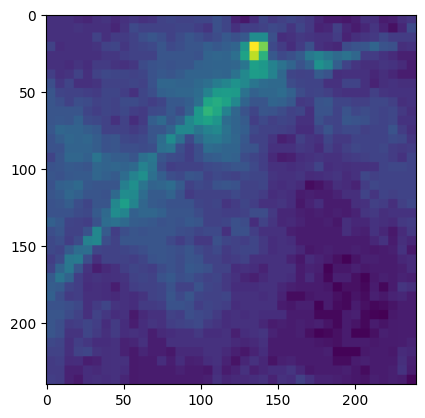

In [ ]:
plt.imshow(img)

# Data Loader Pytorch

In [8]:
da = data["data"]

image_channels = [ch for ch in da.coords["channel"].values if ch != "labels"]

X_da = da.sel(channel=image_channels)
Y_da = da.sel(channel="labels")

In [ ]:
X_da

<xarray.DataArray 'data' (sample: 2803, channel: 11, x: 240, y: 240)> Size: 7GB
[1775980800 values with dtype=float32]
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 264B '442nm' '492nm' '559nm' ... '1610nm' '2186nm'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239

In [ ]:
print(X_da.shape)
print(Y_da.shape)
print(X_da.dims)
print(Y_da.dims)

(2803, 11, 240, 240)
(2803, 240, 240)
('sample', 'channel', 'x', 'y')
('sample', 'x', 'y')


In [28]:
import numpy as np
import torch
from torch.utils.data import Dataset

import numpy as np
import torch
from torch.utils.data import Dataset


class XarraySegmentationDataset(Dataset):
    def __init__(
        self,
        da,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
        label_mapping=None,
    ):
        self.da = da
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        raw_labels = self.da.sel(channel=self.label_channel).values
        unique_labels = np.unique(raw_labels)

        if label_mapping is None:
            self.label_mapping = {old: new for new, old in enumerate(unique_labels)}
        else:
            self.label_mapping = label_mapping

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)

        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        return x.astype(np.float32)

    def _remap_labels(self, y: np.ndarray) -> np.ndarray:
        y_remapped = np.copy(y)
        for old, new in self.label_mapping.items():
            y_remapped[y == old] = new
        return y_remapped.astype(np.int64)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        y = sample.sel(channel=self.label_channel).values

        # Clean raw input first
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self._remap_labels(y)

        x = torch.from_numpy(x)
        y = torch.from_numpy(y)

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

In [29]:
da = data["data"]

dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

x, y = dataset[0]

print("x shape:", x.shape)   # [C, H, W]
print("y shape:", y.shape)   # [H, W]
print("x dtype:", x.dtype)   # torch.float32
print("y dtype:", y.dtype)   # torch.int64

x shape: torch.Size([11, 240, 240])
y shape: torch.Size([240, 240])
x dtype: torch.float32
y dtype: torch.int64


In [30]:
print(dataset.input_channels)

[np.str_('442nm'), np.str_('492nm'), np.str_('559nm'), np.str_('665nm'), np.str_('704nm'), np.str_('739nm'), np.str_('780nm'), np.str_('833nm'), np.str_('864nm'), np.str_('1610nm'), np.str_('2186nm')]


In [31]:
import numpy as np

label_values = np.unique(da.sel(channel="labels").values)
print(label_values)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


In [32]:
import numpy as np

label_values = np.unique(da.sel(channel="labels").values)
print("Unique labels:", label_values)
num_classes = len(label_values)
print("Number of classes:", num_classes)

Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Number of classes: 16


In [33]:
from torch.utils.data import random_split, DataLoader

dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [19]:
train_loader

In [20]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

In [34]:
in_channels = len(dataset.input_channels)
print("Input channels:", in_channels)
print("Classes:", num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=in_channels, num_classes=num_classes).to(device)
print(model)

Input channels: 11
Classes: 16
UNet(
  (down1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(11, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [35]:
batch_x, batch_y = next(iter(train_loader))

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

with torch.no_grad():
    logits = model(batch_x)

print("Input shape: ", batch_x.shape)
print("Target shape:", batch_y.shape)
print("Logits shape:", logits.shape)

loss = criterion(logits, batch_y)
print("Loss:", loss.item())

Input shape:  torch.Size([16, 11, 240, 240])
Target shape: torch.Size([16, 240, 240])
Logits shape: torch.Size([16, 16, 240, 240])
Loss: 2.686187982559204


In [36]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

#check for data sanity

In [ ]:
dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

print("Label mapping:", dataset.label_mapping)
num_classes = len(dataset.label_mapping)
print("Num classes:", num_classes)

In [ ]:
batch_x, batch_y = next(iter(train_loader))

print("batch_x has NaN:", torch.isnan(batch_x).any().item())
print("batch_x has inf:", torch.isinf(batch_x).any().item())
print("batch_x min:", batch_x.min().item())
print("batch_x max:", batch_x.max().item())

print("batch_y has NaN:", torch.isnan(batch_y.float()).any().item())
print("batch_y unique:", torch.unique(batch_y))

#debuging training
#checking if weights change

In [45]:
model = UNet(in_channels=len(dataset.input_channels), num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

In [46]:
model = UNet(in_channels=len(dataset.input_channels), num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

batch_x, batch_y = next(iter(train_loader))
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

model.train()
optimizer.zero_grad()

name, p = next(iter(model.named_parameters()))
before = p.detach().clone()

logits = model(batch_x)
loss = criterion(logits, batch_y)
print("loss:", loss.item())

loss.backward()
optimizer.step()

after = dict(model.named_parameters())[name].detach().clone()

print("changed:", not torch.equal(before, after))
print("mean abs diff:", (after - before).abs().mean().item())

loss: 2.8311848640441895
changed: True
mean abs diff: 0.0009997470770031214


# Training

In [47]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 1/10 | train_loss=0.4984 | val_loss=0.1066
Epoch 2/10 | train_loss=0.0818 | val_loss=0.0650


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

model.eval()

x, y = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    logits = model(x)
    preds = torch.argmax(logits, dim=1)

x = x.cpu()
y = y.cpu()
preds = preds.cpu()

sample_idx = 0
channel_idx = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x[sample_idx, channel_idx].numpy(), cmap="gray")
axes[0].set_title("Input channel 0")
axes[0].axis("off")

axes[1].imshow(y[sample_idx].numpy(), cmap="tab20")
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(preds[sample_idx].numpy(), cmap="tab20")
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()